## Stock Market Trend Analysis

### Week 2. Improved Model Development

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Features Selection & Data Preparation

In [5]:
df = pd.read_csv("modeling_dataset.csv")

In [6]:
df.head(2)

,close,volume,sma_200,atr_14,volume_sma_20,price_to_sma_50,trend_label,sma_20,macd,rsi_14,bb_width,volume_ratio,momentum_10,momentum_20,volatility_20
0,152.81,1467983.0,157.712381,5.467857,1230876.80,-0.031084,Downtrend,157.5925,-2.348076,31.936416,21.594779,1.192632,-5.93,-7.30,0.017942
1,152.62,1417942.0,157.480909,5.266429,1236139.65,-0.030867,Downtrend,157.1055,-2.307113,37.751964,21.541158,1.147073,-6.51,-9.74,0.017535


In [7]:
df.shape

(15482, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15482 entries, 0 to 15481
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   close            15482 non-null  float64
 1   volume           15482 non-null  float64
 2   sma_200          15482 non-null  float64
 3   atr_14           15482 non-null  float64
 4   volume_sma_20    15482 non-null  float64
 5   price_to_sma_50  15482 non-null  float64
 6   trend_label      15482 non-null  object 
 7   sma_20           15482 non-null  float64
 8   macd             15482 non-null  float64
 9   rsi_14           15482 non-null  float64
 10  bb_width         15482 non-null  float64
 11  volume_ratio     15482 non-null  float64
 12  momentum_10      15482 non-null  float64
 13  momentum_20      15482 non-null  float64
 14  volatility_20    15482 non-null  float64
dtypes: float64(14), object(1)
memory usage: 1.8+ MB


### Model Development

In [10]:
# Features separation from the target

features = df.drop("trend_label", axis=1)

In [11]:
label = df["trend_label"]

In [12]:
features.head(2)

,close,volume,sma_200,atr_14,volume_sma_20,price_to_sma_50,sma_20,macd,rsi_14,bb_width,volume_ratio,momentum_10,momentum_20,volatility_20
0,152.81,1467983.0,157.712381,5.467857,1230876.80,-0.031084,157.5925,-2.348076,31.936416,21.594779,1.192632,-5.93,-7.30,0.017942
1,152.62,1417942.0,157.480909,5.266429,1236139.65,-0.030867,157.1055,-2.307113,37.751964,21.541158,1.147073,-6.51,-9.74,0.017535


In [13]:
label.head()

0    Downtrend
1    Downtrend
2     Sideways
3     Sideways
4     Sideways
Name: trend_label, dtype: object

In [14]:
features.columns

Index(['close', 'volume', 'sma_200', 'atr_14', 'volume_sma_20',
       'price_to_sma_50', 'sma_20', 'macd', 'rsi_14', 'bb_width',
       'volume_ratio', 'momentum_10', 'momentum_20', 'volatility_20'],
      dtype='object')

### Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
Xtrain, Xtest, ytrain, ytest = train_test_split(features, label, test_size=0.3, random_state=42)

In [18]:
print(f"Training data size {len(Xtrain)}")
print(f"Testing data size {len(Xtest)}")

Training data size 10837
Testing data size 4645


In [19]:
ytrain.value_counts(normalize=True)*100

trend_label
Uptrend      35.388023
Downtrend    32.499769
Sideways     32.112208
Name: proportion, dtype: float64

### Baseline Model Training & Evaluation-Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

C:\Users\gluzi\anaconda3\envs\StockMarketProject\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Classification Report
              precision    recall  f1-score   support

   Downtrend       0.34      0.15      0.21      1495
    Sideways       0.41      0.05      0.09      1454
     Uptrend       0.37      0.83      0.51      1696

    accuracy                           0.37      4645
   macro avg       0.37      0.34      0.27      4645
weighted avg       0.37      0.37      0.28      4645



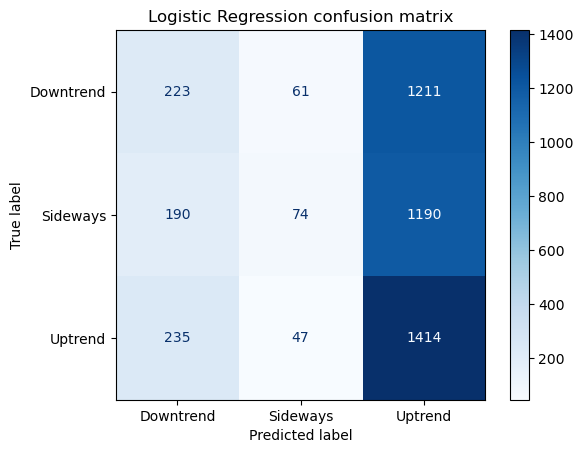

In [22]:
# Model initialization
model = LogisticRegression(random_state=42, max_iter=1000)

# Model fitting
model.fit(Xtrain, ytrain)

# Predictions
predictions = model.predict(Xtest)

# Evaluation
report = classification_report(ytest, predictions)
matrix = confusion_matrix(ytest, predictions, labels=model.classes_) # Confusion matrix with labels

# Display with class names
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=model.classes_)

print("Logistic Regression Classification Report")
print(report)

# Confusion Matrix Heatmap
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression confusion matrix")

plt.savefig("Logistic_Regression_confusion_matrix.png", dpi=300)
plt.show()


### Advanced Model Training & Evaluation-Random Forest 

Random Forest Classifier Report
              precision    recall  f1-score   support

   Downtrend       0.64      0.64      0.64      1495
    Sideways       0.48      0.47      0.48      1454
     Uptrend       0.67      0.68      0.68      1696

    accuracy                           0.60      4645
   macro avg       0.60      0.60      0.60      4645
weighted avg       0.60      0.60      0.60      4645



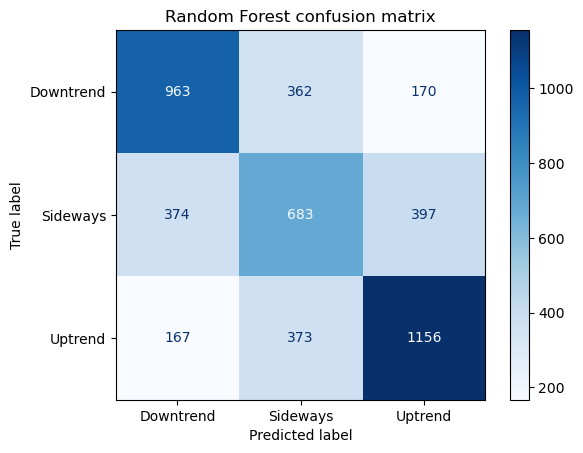

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
#rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100, max_depth=20)

rf_model.fit(Xtrain, ytrain)

predictions_rf = rf_model.predict(Xtest)
report_rf = classification_report(ytest, predictions_rf)
#matrix = confusion_matrix(ytest, predictions)
matrix_rf = confusion_matrix(ytest, predictions_rf, labels=rf_model.classes_)

# Display with class names
disp_rf = ConfusionMatrixDisplay(confusion_matrix=matrix_rf,
                              display_labels=rf_model.classes_)

print("Random Forest Classifier Report")
print(report_rf)

# Confusion Matrix Heatmap
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest confusion matrix")

plt.savefig("Random_Forest_confusion_matrix.png", dpi=300)

plt.show()

#### Hyperparameter Tuning

In [26]:
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid
parameter_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10]
    #"min_samples_leaf": [1, 2, 4]
}

# Initializing the model
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                          param_grid = parameter_grid,
                          scoring="f1",
                          cv=5,
                          n_jobs=-1
                          )

# Training the model
grid_search.fit(Xtrain, ytrain)


C:\Users\gluzi\anaconda3\envs\StockMarketProject\lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [27]:
# Best Parameter

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [28]:
# Training the best model
best_rf = grid_search.best_estimator_

predictions_best_rf = best_rf.predict(Xtest)

print("Fine tuned Random Forest Classifier")
report = classification_report(ytest, predictions_best_rf)
print(report)

Fine tuned Random Forest Classifier
              precision    recall  f1-score   support

   Downtrend       0.51      0.48      0.50      1495
    Sideways       0.40      0.48      0.44      1454
     Uptrend       0.57      0.50      0.54      1696

    accuracy                           0.49      4645
   macro avg       0.50      0.49      0.49      4645
weighted avg       0.50      0.49      0.49      4645



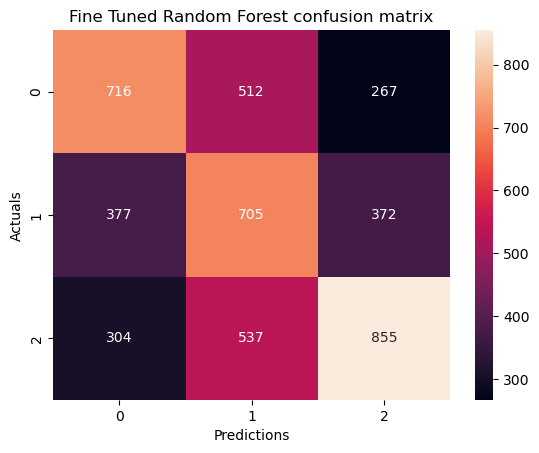

In [29]:
matrix = confusion_matrix(ytest, predictions_best_rf)
sns.heatmap(matrix, annot=True, fmt="g")
plt.xlabel("Predictions")
plt.ylabel("Actuals")
plt.title("Fine Tuned Random Forest confusion matrix")

plt.savefig("Fine_tuned_Random_Forest_confusion_matrix.png", dpi=300)

plt.show()

##### Notes: The untuned Random Forest performance is still better than the above tuned one.

### ROC Curve and AUC Score

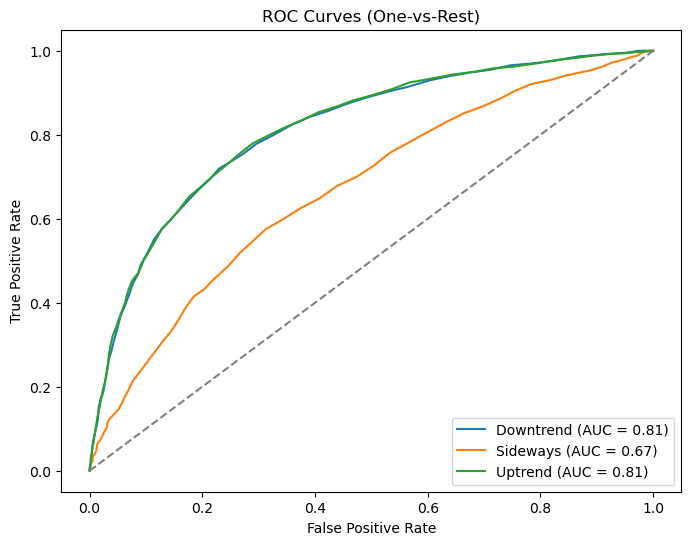

In [32]:
# ROC Curve for the rf_model (UNTUNED but more performant)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
#import matplotlib.pyplot as plt

# Binarize the labels for multiclass ROC
ytest_bin = label_binarize(ytest, classes=rf_model.classes_)
n_classes = ytest_bin.shape[1]

# Predict probabilities
y_probs = rf_model.predict_proba(Xtest)

# Plot ROC curve for each class
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(ytest_bin[:, i], y_probs[:, i])
    auc_score = roc_auc_score(ytest_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f"{rf_model.classes_[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")

plt.savefig("ROC_and_AUC_Curves_Random_Forest.png", dpi=300)

plt.show()


In [33]:
# Macro/Weighted AUC (single summary score) UNTUNED MODEL

auc_macro = roc_auc_score(ytest_bin, y_probs, average="macro")
auc_weighted = roc_auc_score(ytest_bin, y_probs, average="weighted")

print("Macro AUC:", auc_macro)
print("Weighted AUC:", auc_weighted)


Macro AUC: 0.7660238587578402
Weighted AUC: 0.7689768236423496


#### Saving the models (Baseline-LR and Advanced-RF)

In [35]:
import joblib

# Saving the baseline model Logistic Regression(LR)
joblib.dump(model, "logistic_regression_model.pkl")

# Saving the untuned RandomForestClassifier trained model(RF)
joblib.dump(rf_model, "random_forest_model.pkl")


['random_forest_model.pkl']

### Feature Importance

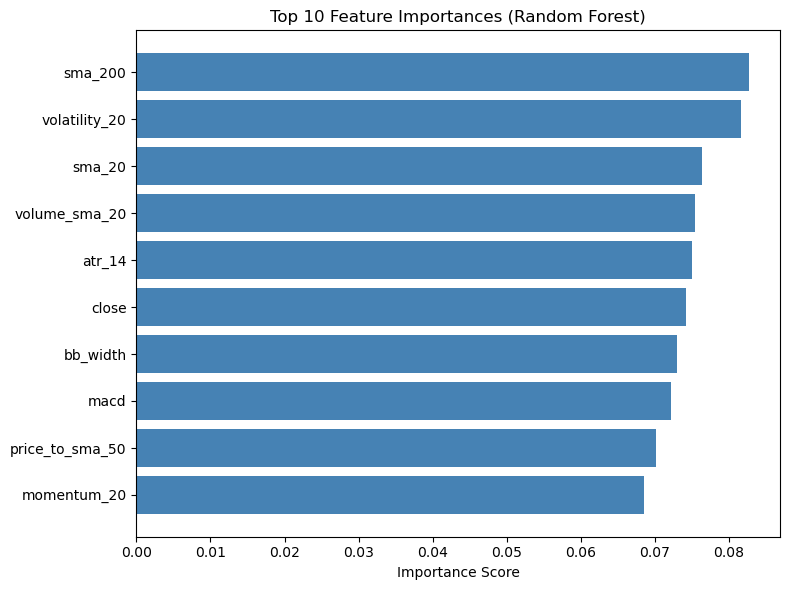

In [37]:
# 1. Getting feature importance from the trained Random Forest
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    #'Feature': feature_names,
    'Feature': features.columns,
    'Importance': importances
})

# 3. Sorting features by importance (descending)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plotting top 10 features
plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['Feature'][:10][::-1],
         feature_importance_df['Importance'][:10][::-1],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()

# Saving the visual as png
plt.savefig("top_10_feature_importance.png", dpi=300)

plt.show()
